In [13]:
from qiskit import QuantumRegister, ClassicalRegister, QuantumCircuit
from qiskit_aer import QasmSimulator
from qiskit.visualization import plot_histogram
import numpy as np
import math
import warnings
warnings.filterwarnings('ignore')

M_simulator = QasmSimulator()

In [14]:
def phase_flip_all_ones(qc, qreg):
    qc.h(qreg[-1])
    qc.mcx(qreg[:-1], qreg[-1])
    qc.h(qreg[-1])

def oracle(qc, qreg, tomark):
    for i in range(len(qreg)):
        if tomark[i] == 0:
            qc.x(qreg[i])

    phase_flip_all_ones(qc, qreg)

    for i in range(len(qreg)):
        if tomark[i] == 0:
            qc.x(qreg[i])

def diffusion_operator(qc, qreg):
    qc.h(qreg)
    qc.x(qreg)
    phase_flip_all_ones(qc, qreg)
    qc.x(qreg)
    qc.h(qreg)

def grover_search(query, shots=1024):
    n = len(query)
    #(2k + 1)·θ  ≈  π/2
    # k ≈ π/(4θ) − 1/2
    # k  ≈  (π/4)·√N

    iterations = math.floor(math.pi/4*math.sqrt(2**n))
    qreg = QuantumRegister(n, 'qreg')
    creg = ClassicalRegister(n, 'creg')
    qc = QuantumCircuit(qreg, creg)
    qc.h(qreg)
    for _ in range(iterations):
        oracle(qc, qreg, query)
        diffusion_operator(qc, qreg)

    qc.measure(qreg, creg)
    job = M_simulator.run(qc, shots=shots)
    result = job.result()
    counts = result.get_counts(qc)
    return counts

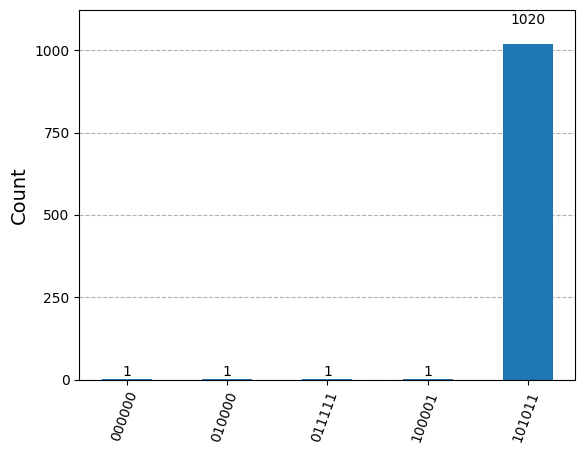

In [ ]:
plot_histogram(grover_search([1,1,0,1]))